#### Импорт библиотек и инициализация необходимых констант

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error

In [2]:
PATH_TO_DATASET: Path = Path("../data/fish.csv")
RANDOM_STATE: int = 716
TEST_SIZE: float = 0.3
DEGREES_FOR_POLYNOMIALS: list[int] = [1, 2, 3, 4]

#### Создание выборки тестовых данных

In [3]:
data = pd.read_csv(PATH_TO_DATASET)
data

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...,...
154,Smelt,12.2,11.5,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,11.7,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,12.1,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,13.2,14.3,15.2,2.8728,2.0672


In [4]:
X = data.drop(columns=["Species", "Weight"])
y = data["Weight"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, shuffle=True)

#### Обучение линейной регрессионной модели при различных параметрах `PolynomialFeatures`

In [6]:
mae_train: list[float] = list()
mae_test: list[float] = list()

for degree in DEGREES_FOR_POLYNOMIALS:
    model = LinearRegression()
    poly = PolynomialFeatures(degree=degree, include_bias=False, interaction_only=False)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model.fit(X_train_poly, y_train)
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    mae_train.append(mean_absolute_error(y_train, y_train_pred))
    mae_test.append(mean_absolute_error(y_test, y_test_pred))

#### График MAE для Train/Test при разных `degree = {1, 2, 3, 4}`

Можно увидеть как при увеличении степени для `PolynomialFeatures` усиливается эффект переобучения линейной регрессионной модели

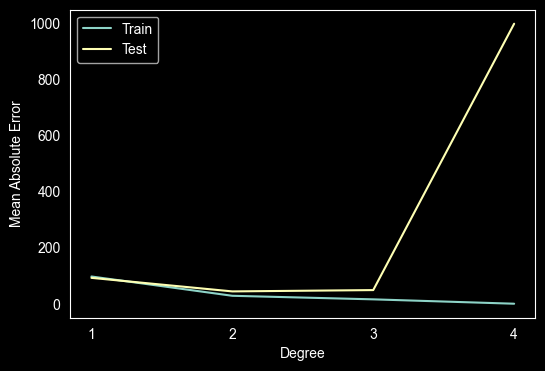

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(DEGREES_FOR_POLYNOMIALS, mae_train, label="Train")
ax.plot(DEGREES_FOR_POLYNOMIALS, mae_test, label="Test")
ax.set_xlabel("Degree")
ax.set_xticks(DEGREES_FOR_POLYNOMIALS)
ax.set_ylabel("Mean Absolute Error")
ax.legend()
ax.grid(False)

plt.show()